In [1]:
import sys
import os
import warnings
import time
import inspect
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
from matplotlib import pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split

# Addthe parent directory to the system path to access the 'src' module.
# Assuming this notebook resides in 'notebooks/', '..' resolves to the project root.
sys.path.append(os.path.abspath('..'))

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.width', 500)

train_path = "../data/train.csv"
test_path = "../data/test.csv"

def load_data(path):
    data = pd.read_csv(path)
    return data

df = load_data(train_path)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S


In [2]:
test_df = load_data(test_path)
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.500,0,0,330911,7.829,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.000,1,0,363272,7.000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.000,0,0,240276,9.688,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.000,0,0,315154,8.662,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.000,1,1,3101298,12.287,NaN,S


In [3]:
def check_df(dataframe, head=5):
    print("##################### Shape #####################")
    print(dataframe.shape)
    print("##################### Info #####################")
    print(dataframe.info())
    print("##################### Types #####################")
    display(dataframe.dtypes.to_frame("Type"))
    print("##################### Head #####################")
    display(dataframe.head(head))
    print("##################### Tail #####################")
    display(dataframe.tail(head))
    print("##################### Describe #####################")
    display(dataframe.describe([0, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1]).T)
    print("\n###################### Unique Value Counts per Column ######################")
    display(dataframe[dataframe.columns].nunique())
    print("##################### NA #####################")
    display(dataframe.isnull().sum().to_frame("Missing Values"))

check_df(df)

##################### Shape #####################
(891, 12)
##################### Info #####################
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
##################### Types #####################


,Type
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


##################### Head #####################


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S


##################### Tail #####################


...

,count,mean,std,min,0%,5%,25%,50%,75%,95%,99%,100%,max
PassengerId,891.000,446.000,257.354,1.000,1.000,45.500,223.500,446.000,668.500,846.500,882.100,891.000,891.000
Survived,891.000,0.384,0.487,0.000,0.000,0.000,0.000,0.000,1.000,1.000,1.000,1.000,1.000
Pclass,891.000,2.309,0.836,1.000,1.000,1.000,2.000,3.000,3.000,3.000,3.000,3.000,3.000
Age,714.000,29.699,14.526,0.420,0.420,4.000,20.125,28.000,38.000,56.000,65.870,80.000,80.000
SibSp,891.000,0.523,1.103,0.000,0.000,0.000,0.000,0.000,1.000,3.000,5.000,8.000,8.000
Parch,891.000,0.382,0.806,0.000,0.000,0.000,0.000,0.000,0.000,2.000,4.000,6.000,6.000
Fare,891.000,32.204,49.693,0.000,0.000,7.225,7.910,14.454,31.000,112.079,249.006,512.329,512.329



###################### Unique Value Counts per Column ######################


PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

##################### NA #####################


,Missing Values
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [4]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    """
    Returns the names of categorical, numerical, and categorical but cardinal columns in the dataset.
    
    Note: Categorical columns also include those that are numerically-coded but categorical in nature.
    
    Parameters
    ----------
        dataframe: pandas.DataFrame
                The dataframe from which the column names are to be extracted.
        cat_th: int, optional
                The threshold for the number of unique values to classify a numerical column as categorical.
        car_th: int, optional
                The threshold for the number of unique values to classify a categorical column as cardinal.
    
    Returns
    -------
        cat_cols: list
                A list of the names of categorical columns.
        num_cols: list
                A list of the names of numerical columns.
        cat_but_car: list
                A list of the names of categorical columns that are considered cardinal.
        num_but_cat: list
                A list of the names of numerical columns that are considered categorical.
    
    Examples
    --------
        import seaborn as sns
        df = sns.load_dataset("iris")
        print(grab_col_names(df))
    
    Notes
    -----
        - The sum of the lengths of cat_cols, num_cols, and cat_but_car equals the total number of columns.
        - Columns identified as "numeric but categorical" are included within the cat_cols list.
        - The total number of columns is equal to the sum of the lengths of the three returned lists: len(cat_cols) + len(num_cols) + len(cat_but_car).

    """

    # cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() <= cat_th and dataframe[col].dtypes != "O"]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and dataframe[col].dtypes == "O"]

    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # num_cols
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f"cat_cols: {len(cat_cols)}")
    print(f"num_cols: {len(num_cols)}")
    print(f"cat_but_car: {len(cat_but_car)}")
    print(f"num_but_cat: {len(num_but_cat)}")

    return cat_cols, num_cols, cat_but_car, num_but_cat

cat_cols, num_cols, cat_but_car, num_but_cat = grab_col_names(df)

num_cols = [col for col in num_cols if col not in "PassengerId"]

Observations: 891
Variables: 12
cat_cols: 6
num_cols: 3
cat_but_car: 3
num_but_cat: 4


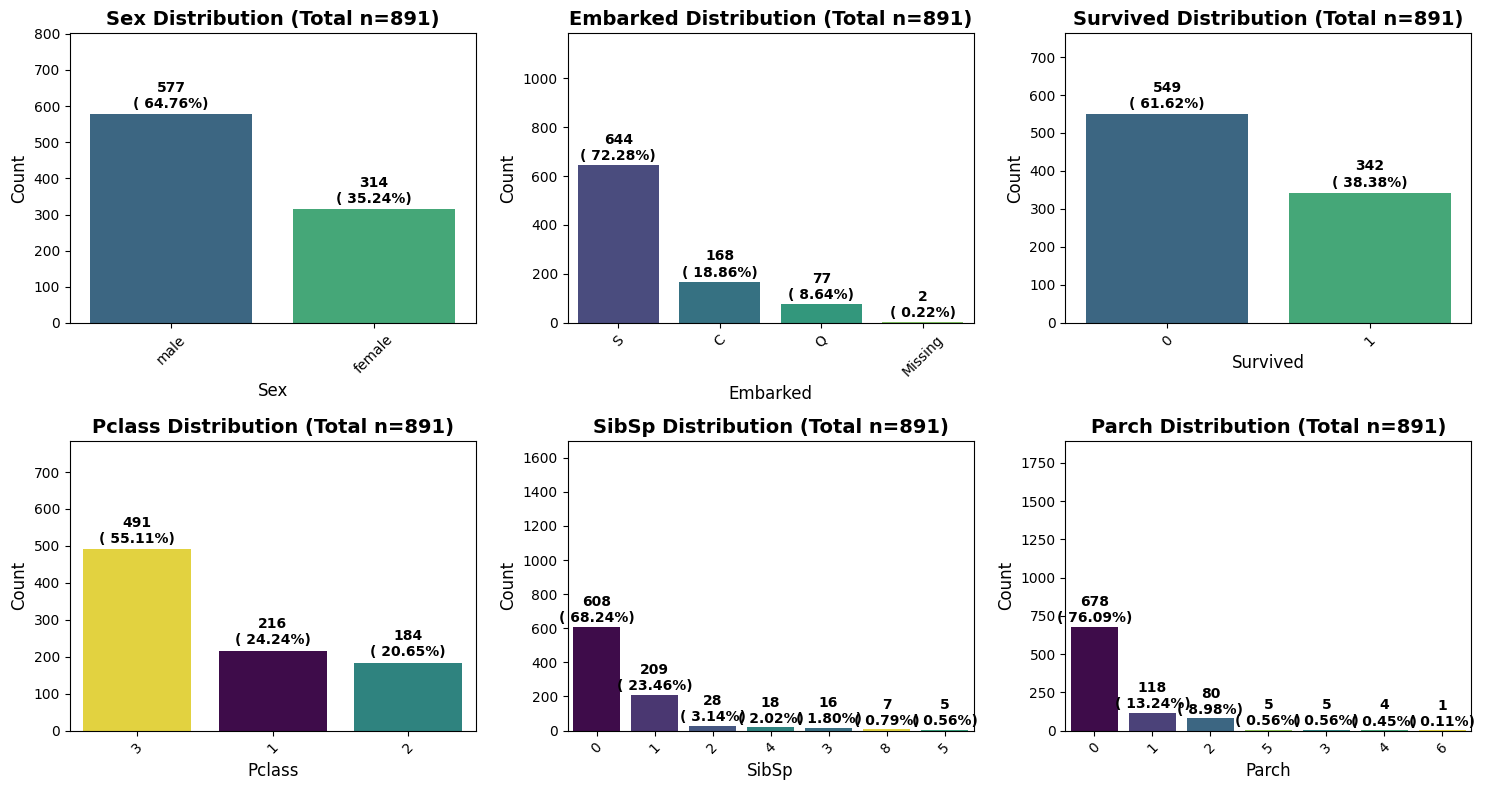

In [5]:
def cat_summary(dataframe, col_name, plot=False, ax=None):
    if dataframe[col_name].dtypes == "bool":
        dataframe[col_name] = dataframe[col_name].astype(int)
    value_counts = dataframe[col_name].value_counts(dropna=False)
    ratio = 1000 * value_counts / len(dataframe)
    summary_df = pd.DataFrame({col_name: value_counts, "Ratio:%": ratio.round(2)})
    n_missing = dataframe[col_name].isnull().sum()
    #print(f"\n{'#'*50}")
    #print(f"Column: {col_name}")
    #print(f"{'#'*50}")
    #print(summary_df,"\n")
    if n_missing > 0:
        #print(f"Column: {col_name} has missing rate: {n_missing} ({100*n_missing/len(dataframe):.2f}%)\n")
        pass
    if plot:
        plot_data = dataframe[[col_name]].copy()
        plot_data[col_name] = plot_data[col_name].fillna("Missing")
        order = plot_data[col_name].value_counts().index

        if ax is None:
            plt.figure(figsize=(12, 6))
            ax = plt.gca()

        sns.countplot(x=col_name, data=plot_data, order=order, hue=col_name, palette="viridis", legend=False, ax=ax)
        total = len(plot_data)
        for p in ax.patches:
            height = p.get_height()
            pct = 100 * height / total 
            ax.annotate(f"{int(height)}\n({pct: .2f}%)",
                       (p.get_x() + p.get_width() / 2., height + total * 0.01),
                       ha="center", va="bottom", fontsize=10, fontweight="bold")
            ax.set_title(f"{col_name} Distribution (Total n={total})", fontsize=14, fontweight="bold")
            ax.set_xlabel(col_name, fontsize=12)
            ax.set_ylabel("Count", fontsize=12)
            ax.tick_params(axis="x", rotation=45)
            ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

            if ax is None:
                plt.tight_layout()
                plt.show(block=True)

# Display all graphs in a single plot
def plot_all_categories(dataframe, cat_cols, cols_per_row=3, save=False, filename="cat_summary.png"):
    n_cols = len(cat_cols)
    n_rows = (n_cols + cols_per_row - 1) // cols_per_row
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(5*cols_per_row, 4*n_rows))
    axes = axes.flatten()

    for idx, col in enumerate(cat_cols):
        cat_summary(dataframe, col, plot=True, ax=axes[idx])

    for idx in range(n_cols, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()

    if save:
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        print(f"Plot saved: {filename}")

    plt.show()

plot_all_categories(df, cat_cols)   # Don't save
# plot_all_categories(df, cat_cols, save=True)  # Save with default name
# plot_all_categories(df, cat_cols, save=True, filename="analyse.png")  # Save with special name

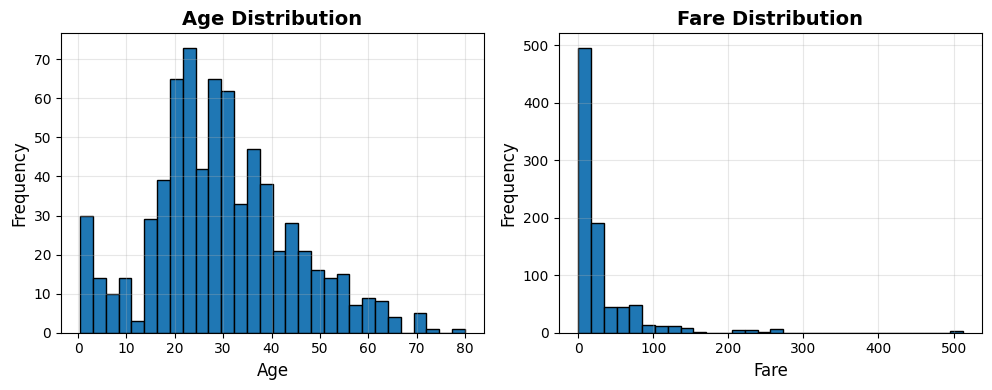

In [6]:
def num_summary(dataframe, numerical_col, plot=False, ax=None):
    missing_count = dataframe[numerical_col].isna().sum()
    missing_pct = 100 * missing_count / len(dataframe)
    #print("#######################################################")
    #print(f"Column: {numerical_col} \nMissing Value Count: {missing_count} \nMissing Value Percentage: {missing_pct:.2f}%\n")
    #quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    #print(dataframe[numerical_col].describe(quantiles).T, "\n")

    if plot:
        if ax is None:
            plt.figure(figsize=(10, 6))
            ax = plt.gca()

        dataframe[numerical_col].hist(ax=ax, bins=30, edgecolor="black")
        ax.set_xlabel(numerical_col, fontsize=12)
        ax.set_ylabel("Frequency", fontsize=12)
        ax.set_title(f"{numerical_col} Distribution", fontsize=14, fontweight="bold")
        ax.grid(alpha=0.3)

        if ax is None:
            plt.tight_layout()
            plt.show(block=True)

# Display all graphs in a single plot
def plot_all_numerical(dataframe, num_cols, cols_per_row=3, save=False, filename="num_summary.png"):
    n_cols = len(num_cols)
    n_rows = (n_cols + cols_per_row - 1) // cols_per_row
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(5*cols_per_row, 4*n_rows))
    axes = axes.flatten()

    for idx, col in enumerate(num_cols):
        num_summary(dataframe, col, plot=True, ax=axes[idx])

    # Hide unused subplots
    for idx in range(n_cols, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()

    if save:
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        print(f"Plot saved: {filename}")

    plt.show()

plot_all_numerical(df, num_cols)  # Don't save
# plot_all_numerical(df, num_cols, save=True)  # Save with default name
# plot_all_numerical(df, num_cols, cols_per_row=3, save=True, filename="numerical_analysis.png")  # Save with special name

In [7]:
def target_summary_with_cat(dataframe, target, categorical_col):
    """
    Displays the target mean for each class of the categorical variable (including NaN).
    
    Parameters
    ----------
    dataframe : pd.DataFrame
        The dataframe to analyse the relationship between the categorical feature and the target feature.
    target : str
        Target feature ('Survived')
    categorical_col : str
        Categorical feature
    
    Examples
    --------
    target_summary_with_cat(df, "Survived", "Embarked")
    """
    # Temporarily fill NaNs with "Missing" (without altering the original data)
    temp_cat_col = dataframe[categorical_col].fillna("Missing")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = pd.DataFrame({
            "COUNT": temp_cat_col.value_counts(),
            "RATIO": 100 * temp_cat_col.value_counts() / len(dataframe),
            "TARGET_MEAN": dataframe.groupby(temp_cat_col)[target].mean(),
            "TARGET_MEDIAN": dataframe.groupby(temp_cat_col)[target].median()
        }).sort_values("TARGET_MEAN", ascending=False)
    print(f"\n{'='*70}")
    print(f"{categorical_col} → {target}")
    print(f"{'='*70}")
    print(result, "\n")

# For categorical variables (NaN values will appear as Missing)
for col in cat_cols:
    target_summary_with_cat(df, "Survived", col)


Sex → Survived
        COUNT  RATIO  TARGET_MEAN  TARGET_MEDIAN
Sex                                             
female    314 35.241        0.742          1.000
male      577 64.759        0.189          0.000 


Embarked → Survived
          COUNT  RATIO  TARGET_MEAN  TARGET_MEDIAN
Embarked                                          
Missing       2  0.224        1.000          1.000
C           168 18.855        0.554          1.000
Q            77  8.642        0.390          0.000
S           644 72.278        0.337          0.000 


Survived → Survived
          COUNT  RATIO  TARGET_MEAN  TARGET_MEDIAN
Survived                                          
1           342 38.384        1.000          1.000
0           549 61.616        0.000          0.000 


Pclass → Survived
        COUNT  RATIO  TARGET_MEAN  TARGET_MEDIAN
Pclass                                          
1         216 24.242        0.630          1.000
2         184 20.651        0.473          0.000
3         491 5

In [8]:
def target_summary_with_num(dataframe, target, numerical_col):
    """
    Displays descriptive statistics of a numerical variable grouped by the target variable.

    Since 'Survived' is binary (0 = did not survive, 1 = survived), we group
    directly by the target instead of trying to bin it into quartiles.
    This lets us compare, e.g., the age distribution of survivors vs. non-survivors.

    Parameters
    ----------
    dataframe : pd.DataFrame
        The dataframe containing both the target and the numerical column.
    target : str
        Binary target variable (e.g. 'Survived': 0 or 1).
    numerical_col : str
        Numerical variable to summarise (e.g. 'Age', 'Fare').

    Examples
    --------
    target_summary_with_num(df, "Survived", "Age")
    """
    # Group by the binary target (0 / 1) and compute descriptive stats
    result = dataframe.groupby(target)[numerical_col].agg([
        ("COUNT",  "count"),
        ("MEAN",   "mean"),
        ("MEDIAN", "median"),
        ("STD",    "std"),
        ("MIN",    "min"),
        ("MAX",    "max")
    ]).round(2)

    print(f"\n{'='*70}")
    print(f"{numerical_col} by {target}  (0 = Did Not Survive, 1 = Survived)")
    print(f"{'='*70}")
    print(result)
    print()

# Compare each numerical variable across Survived = 0 and Survived = 1
for col in num_cols:
    target_summary_with_num(df, "Survived", col)


Age by Survived  (0 = Did Not Survive, 1 = Survived)
          COUNT   MEAN  MEDIAN    STD   MIN    MAX
Survived                                          
0           424 30.630  28.000 14.170 1.000 74.000
1           290 28.340  28.000 14.950 0.420 80.000


Fare by Survived  (0 = Did Not Survive, 1 = Survived)
          COUNT   MEAN  MEDIAN    STD   MIN     MAX
Survived                                           
0           549 22.120  10.500 31.390 0.000 263.000
1           342 48.400  26.000 66.600 0.000 512.330



Observations: 891
Variables: 12
cat_cols: 6
num_cols: 3
cat_but_car: 3
num_but_cat: 4


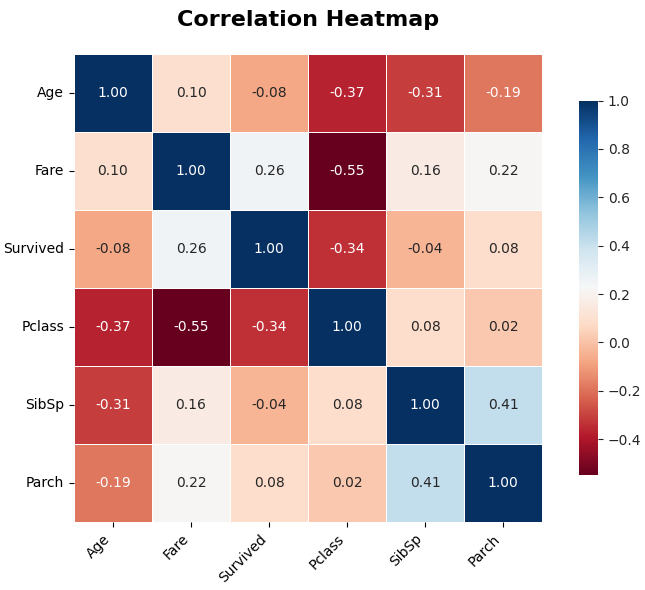

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Correlation Heatmap'}>,
             Age   Fare  Survived  Pclass  SibSp  Parch
 Age       1.000  0.096    -0.077  -0.369 -0.308 -0.189
 Fare      0.096  1.000     0.257  -0.549  0.160  0.216
 Survived -0.077  0.257     1.000  -0.338 -0.035  0.082
 Pclass   -0.369 -0.549    -0.338   1.000  0.083  0.018
 SibSp    -0.308  0.160    -0.035   0.083  1.000  0.415
 Parch    -0.189  0.216     0.082   0.018  0.415  1.000)

In [9]:
def plot_correlation_heatmap(dataframe,
                             columns=None,
                             figsize=(8, 6),
                             cmap="RdBu",
                             annot_format=".2f",
                             save=False,
                             filename="correlation_heatmap.png",
                             title=None):
    """
    Plots a correlation heatmap for numerical features.
    
    Parameters:
    -----------
    dataframe : pd.DataFrame
        Input dataframe
    columns : list, optional
        List of columns to include. If None, uses all numeric columns
    figsize : tuple, default (20, 20)
        Figure size (width, height)
    cmap : str, default "RdBu"
        Colourmap for heatmap (e.g., "RdBu", "coolwarm", "viridis")
    annot_format : str, default ".2f"
        Format for annotation values (e.g., ".2f", ".3f", ".1%")
    save : bool, default False
        Whether to save the figure
    filename : str, default "correlation_heatmap.png"
        Filename for saved figure (only used if save=True)
    title : str, optional
        Title for the plot. If None, uses default title
    
    Returns:
    --------
    tuple : (fig, ax, corr_matrix)
        Figure, axes, and correlation matrix
    """

    if columns is None:
        # Auto-detect numeric columns using grab_col_names
        _, numeric, _, numeric_but_cat = grab_col_names(dataframe)

        # Remove Id column
        numeric = [col for col in numeric if col not in ["PassengerId"]]

        # Include numeric but categorical columns
        columns = numeric + numeric_but_cat

    # Calculate correlation matrix
    corr_matrix = dataframe[columns].corr()

    # PLot
    fig, ax, = plt.subplots(figsize=figsize)

    with sns.axes_style("darkgrid"):
        sns.heatmap(corr_matrix,
                    annot=True,
                    fmt=annot_format,
                    cmap=cmap,
                    square=True,
                    linewidths=0.5,
                    cbar_kws={"shrink": 0.8},
                    ax=ax
                    )
        
    if title is None:
        title = "Correlation Heatmap"
    ax.set_title(title, fontsize=16, fontweight="bold", pad=20)

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    if save:
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        print(f"The heatmap has been saved as: {filename}")

    plt.show()

    return fig, ax, corr_matrix

plot_correlation_heatmap(df)  # Don't save

In [10]:
_cramers_v_cache = {}

def cramers_v(x, y):
    """
    Calculate Cramér's V statistic for categorical-categorical association.
    Calculate Cramér's V statistic with manual caching.

    Cramér's V is a measure of association between two nominal variables,
    giving a value between 0 and 1 (inclusive).
    - 0.0-0.1: No or very weak association
    - 0.1-0.3: Weak association
    - 0.3-0.5: Moderate association
    - 0.5-0.7: Strong association
    - 0.7-1.0: Very strong association
    
    Parameters
    ----------
    x : pd.Series
        First categorical variable
    y : pd.Series
        Second categorical variable
    
    Returns
    -------
    float
        Cramér's V value (0-1)
    
    Examples
    --------
        cramers_v(df['MSZoning'], df['Neighborhood'])
    
    Notes
    -----
        Uses bias correction for better accuracy with small samples.
    """
    # Create cache key: use columns names (memory efficient)
    cache_key = (x.name, y.name) if hasattr(x, "name") and hasattr(y, "name") else None

    # If in cache, return directly
    if cache_key and cache_key in _cramers_v_cache:
        return _cramers_v_cache[cache_key]
    
    # Otherwise calculate
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    result = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

    # Cache the result
    if cache_key:
        _cramers_v_cache[cache_key] = result
        # Also cache the reverse key (symmetric matrix)
        _cramers_v_cache[(y.name, x.name)] = result

    return result

def categorical_correlation_matrix(dataframe, cat_cols):
    """
    Create a correlation matrix for categorical variables using Cramér's V.
    
    Parameters
    ----------
    dataframe : pd.DataFrame
        The dataframe containing categorical variables
    cat_cols : list
        List of categorical column names
    
    Returns
    -------
    pd.DataFrame
        Correlation matrix with Cramér's V values (0-1)
    
    Examples
    --------
        cat_corr = categorical_correlation_matrix(df, cat_cols)
        display(cat_corr)
    
    Notes
    -----
        - NaN values are temporarily filled with "None" for calculation
        - Returns a symmetric matrix (V(X,Y) = V(Y,X))
        - Diagonal values are 1.0 (perfect correlation with itself)
    """
    # Temporarily fill NaN value with "Missing"
    df_temp = dataframe[cat_cols].fillna("Missing")

    # Initialize correlation matrix
    n = len(cat_cols)
    corr_matrix = pd.DataFrame(np.zeros((n, n)), index=cat_cols, columns=cat_cols)
    print("="*70)
    print("CALCULATING CRAMÉR'S V CORRELATION MATRIX")
    print("="*70)
    print(f"Number of categorical variables: {n}")
    print(f"Total pairs to calculate: {n*(n-1)//2}\n")

    # Calculate Cramer's V for each pair
    for i, col1 in enumerate(cat_cols):
        for j, col2 in enumerate(cat_cols):
            if i == j:
                corr_matrix.loc[col1, col2] = 1.0 # Perfect correlation with itself
            elif i < j: # Calculate only upper triangle (symmetric matrix)
                try:
                    v = cramers_v(df_temp[col1], df_temp[col2])
                    corr_matrix.loc[col1, col2] = v
                    corr_matrix.loc[col2, col1] = v # Symmetric
                except Exception as e:
                    print(f"Warning: Could not calculate for {col1} x {col2}: {str(e)}")
                    corr_matrix.loc[col1, col2] = 0
                    corr_matrix.loc[col2, col1] = 0

    print("Correlation matrix calculated successfully!")
    print("="*70, "\n")
    
    return corr_matrix

CALCULATING CRAMÉR'S V CORRELATION MATRIX
Number of categorical variables: 6
Total pairs to calculate: 15

Correlation matrix calculated successfully!


Categorical Correlation Matrix:


,Sex,Embarked,Survived,Pclass,SibSp,Parch
Sex,1.000,0.125,0.540,0.130,0.206,0.247
Embarked,0.125,1.000,0.173,0.264,0.061,0.000
Survived,0.540,0.173,1.000,0.337,0.187,0.157
Pclass,0.130,0.264,0.337,1.000,0.148,0.022
SibSp,0.206,0.061,0.187,0.148,1.000,0.240
Parch,0.247,0.000,0.157,0.022,0.240,1.000


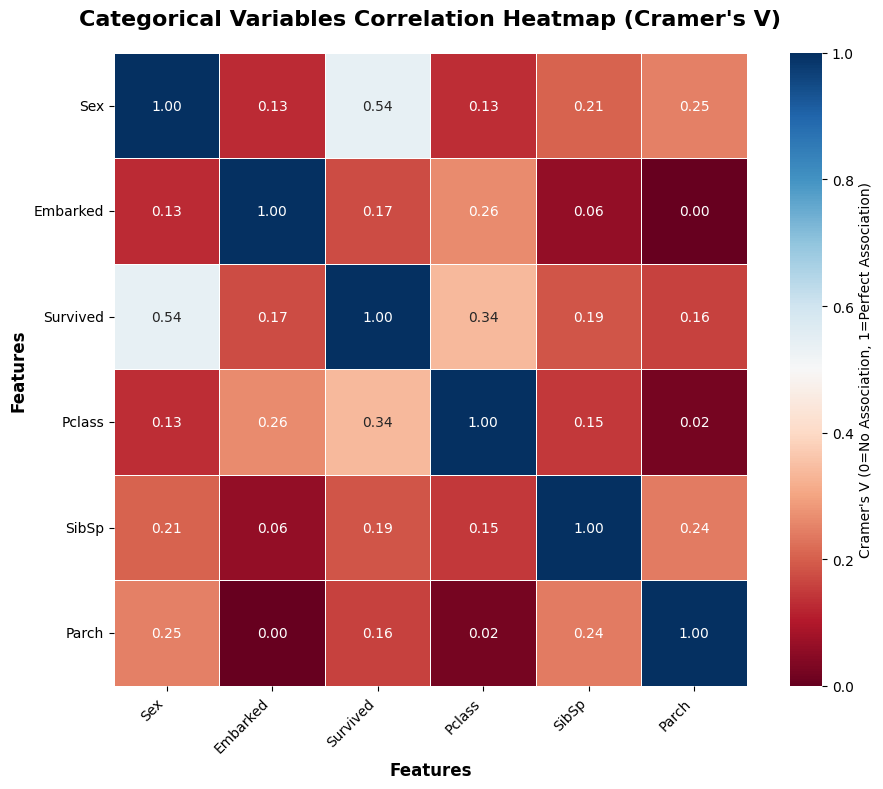


STRONGEST CATEGORICAL ASSOCIATIONS (Cramér's V)

Top 10 strongest correlations:
----------------------------------------------------------------------
 1. Sex                  <-> Survived             : 0.540 (Moderate)
 2. Survived             <-> Pclass               : 0.337 (Weak)
 3. Embarked             <-> Pclass               : 0.264 (Weak)
 4. Sex                  <-> Parch                : 0.247 (Weak)
 5. SibSp                <-> Parch                : 0.240 (Weak)
 6. Sex                  <-> SibSp                : 0.206 (Weak)
 7. Survived             <-> SibSp                : 0.187 (None or Very Weak)
 8. Embarked             <-> Survived             : 0.173 (None or Very Weak)
 9. Survived             <-> Parch                : 0.157 (None or Very Weak)
10. Pclass               <-> SibSp                : 0.148 (None or Very Weak)



In [11]:
def plot_categorical_correlation_heatmap(corr_matrix, figsize=(10,8), annot=False, save=False, filename="categorical_correlation.png"):
    """
    Plot a heatmap of categorical correlations using Cramér's V.
    
    Parameters
    ----------
    corr_matrix : pd.DataFrame
        Correlation matrix from categorical_correlation_matrix()
    figsize : tuple, optional
        Figure size (width, height), by default (18, 16)
    annot : bool, optional
        Whether to annotate cells with values, by default False
        Set to True for small matrices (<15 variables)
    save : bool, optional
        Whether to save the plot, by default False
    filename : str, optional
        Filename if saving, by default "categorical_correlation.png"
    
    Examples
    --------
        plot_categorical_correlation_heatmap(cat_corr, figsize=(20, 18), annot=False)
        plot_categorical_correlation_heatmap(cat_corr, annot=True, save=True, filename="cat_corr.png")
    
    Notes
    -----
        - Colour map: YlOrRd (Yellow to Orange to Red)
        - Yellow (0.0): No association
        - Red (1.0): Perfect association
    """
    plt.figure(figsize=figsize)

    # Create heatmap
    sns.heatmap(corr_matrix,
                annot=annot,
                fmt=".2f",
                cmap="RdBu",
                square=True,
                linewidths=0.5,
                cbar_kws={"label": "Cramer's V (0=No Association, 1=Perfect Association)"},
                vmin=0,
                vmax=1
                )
    
    plt.title("Categorical Variables Correlation Heatmap (Cramer's V)",
              fontsize=16, fontweight="bold", pad=20)
    plt.xlabel("Features", fontsize=12, fontweight="bold")
    plt.ylabel("Features", fontsize=12, fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    if save:
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        print(f"Plot saved: {filename}")

    plt.show()

    # Print strongest associations
    print("\n" + "="*70)
    print("STRONGEST CATEGORICAL ASSOCIATIONS (Cramér's V)")
    print("="*70)

    # Get upper triangle only (avoid duplicates)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    strong_corr = corr_matrix.where(mask).stack().sort_values(ascending=False)

    print("\nTop 10 strongest correlations:")
    print("-"*70)
    for idx, (pair, value) in enumerate(strong_corr.head(10).items(), 1):
        if value > 0.8:
            strength = "Very Strong"
        elif value > 0.6:
            strength = "Strong"
        elif value > 0.4:
            strength = "Moderate"
        elif value > 0.2:
            strength = "Weak"
        else:
            strength = "None or Very Weak"

        print(f"{idx:2d}. {pair[0]:20s} <-> {pair[1]:20s} : {value:.3f} ({strength})")
    print("="*70, "\n")

# Calculate categorical correlation matrix
cat_corr = categorical_correlation_matrix(df, cat_cols)

# Display the matrix
print("\nCategorical Correlation Matrix:")
display(cat_corr)

# Plot heatmap (without annotations for better visualization)
# plot_categorical_correlation_heatmap(cat_corr, figsize=(18, 16), annot=False)

# Optional: Plot with annotations (if you have few variables)
plot_categorical_correlation_heatmap(cat_corr, annot=True)

# Optional: Save the plot
# plot_categorical_correlation_heatmap(cat_corr, save=True, filename="house_prices_cat_correlation.png")

In [12]:
# Separate target if it exists, otherwise use the whole dataframe for splitting
target_col = "Survived"
if target_col in df.columns:
    X = df.drop(target_col, axis=1)
    y = df[target_col]
else:
    X = df.copy()
    y = None

# Split the data: %80 Train, 20% Validation
# Using a fixed random state for reproducibility
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# Recombine X and y for the training set only (as our handler learns from the dataframe context)
train_df = X_train.copy()
if y_train is not None:
    train_df[target_col] = y_train

# Validation set (without target, as we won't use it for training)
valid_df = X_valid.copy()
# Note: We do not add the target to valid_df to prevent accidental leakage usage, 
# though for validation evaluation you will use y_valid separately.

print(f"Data Split Complete:")
print(f"Train Shape: {train_df.shape}")
print(f"Valid Shape: {valid_df.shape}")

Data Split Complete:
Train Shape: (712, 12)
Valid Shape: (179, 11)


In [13]:
def analyse_missing_values(dataframe, plot=True):
    """
    Analyses missing values in the dataframe and displays detailed statistics.
    
    Parameters
    ----------
    dataframe : pandas.DataFrame
        The dataframe to analyse.
    plot : bool, optional
        Whether to visualize the missing data matrix.
        
    Returns
    -------
    missing_df : pandas.DataFrame
        Summary dataframe of missing values sorted by percentage.
    """
    missing_counts = dataframe.isnull().sum()
    missing_pct = 100 * missing_counts / len(dataframe)

    missing_df = pd.DataFrame({
        "Missing Count": missing_counts,
        "Missing Percentage": missing_pct.round(2)
        })
    
    missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values("Missing Percentage", ascending=False) 

    print("-" * 50)
    print("MISSING VALUES ANALYSIS")
    print("-" * 50)
    print(f"Total rows: {len(dataframe)}")
    print(f"Columns with missing values: {len(missing_df)} / {len(dataframe.columns)}")

    if not missing_df.empty:
        display(missing_df)
        if plot:
            plt.figure(figsize=(12, 6))
            msno.matrix(dataframe)
            plt.title("Missing Values Matrix", fontsize=14, fontweight="bold")
            plt.show()
    else:
        print("No missing values found.")

    return missing_df

Sex
female   27.000
male     29.000
Name: Age, dtype: float64



Count    Mean  Median     Std
Embarked Pclass                               
C        1          57 116.020  79.200 112.390
         2          16  26.140  25.860  11.240
         3          52  10.930   7.900   5.070
Q        1           2  90.000  90.000   0.000
         2           3  12.350  12.350   0.000
         3          55  11.400   7.750   6.860
S        1         102  74.470  53.100  61.400
         2         132  20.090  14.250  12.960
         3         291  14.950   8.050  13.840

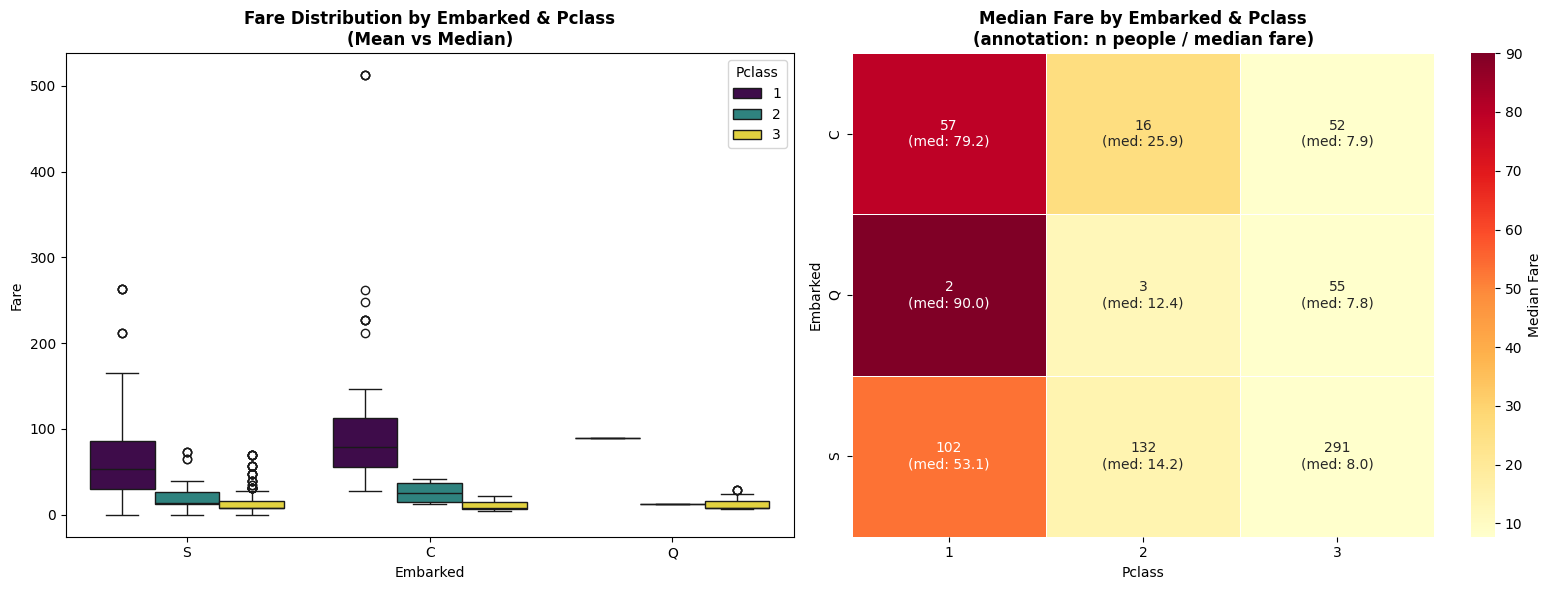

In [14]:
# --- Fare & Age Analysis by Demographic Groups ---
# Median age is calculated per sex to inform future missing-value imputation
# (male and female passengers had meaningfully different age distributions).
#
# Fare is then broken down by both Embarked port and Pclass because the two
# interact strongly: passengers from different ports tended to board in
# different ticket classes, creating skewed fare distributions within each
# group. Understanding this overlap is necessary before deciding how to
# handle the two missing Embarked values and the one missing Fare value in
# the dataset.
#
# The side-by-side visualisation — a boxplot (spread + outliers) and a
# heatmap (median fare coloured, passenger count annotated) — makes it easy
# to spot which group combinations are sparse or anomalous, which informs
# both imputation strategy and feature engineering decisions later.

age_stats = train_df.groupby("Sex")["Age"].median()
print(age_stats)
print("\n" + "="*70)

fare_stats = train_df.groupby(["Embarked", "Pclass"])["Fare"].agg(
    Count="count",
    Mean="mean",
    Median="median",
    Std="std"
).round(2)

display(fare_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Boxplot - Fare distribution (Embarked x Pclass) ---
train_df_plot = train_df.dropna(subset=["Embarked", "Fare"])
sns.boxplot(
    data=train_df_plot,
    x="Embarked", y="Fare", hue="Pclass",
    palette="viridis", ax=axes[0], showfliers=True
)
axes[0].set_title("Fare Distribution by Embarked & Pclass\n(Mean vs Median)", fontweight="bold")
axes[0].set_xlabel("Embarked")
axes[0].set_ylabel("Fare")
axes[0].legend(title="Pclass")

# --- Right: Count heatmap - number of people in each group ---
count_pivot = train_df.groupby(["Embarked", "Pclass"])["Fare"].count().unstack()
median_pivot = train_df.groupby(["Embarked", "Pclass"])["Fare"].median().unstack()

# Heatmap: colour = median fare, annotation = count
annot_labels = count_pivot.astype(str) + "\n(med: " + median_pivot.round(1).astype(str) + ")"

sns.heatmap(
    median_pivot,
    annot=annot_labels,
    fmt="",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=axes[1],
    cbar_kws={"label": "Median Fare"}
)
axes[1].set_title("Median Fare by Embarked & Pclass\n(annotation: n people / median fare)", fontweight="bold")
axes[1].set_xlabel("Pclass")
axes[1].set_ylabel("Embarked")

plt.tight_layout()
plt.show()

In [15]:
def create_missing_value_handler(train_df, verbose=True):
    """
    Creates a closure (handler function) that encapsulates parameters learnt 
    strictly from the training data. This ensures no data leakage occurs 
    when applying the strategy to validation or test sets.

    This function implements domain-specific strategies for the Titanic dataset:
    - Age: fills with sex-based median (male/female age distributions differ)
    - Embarked: infers the most likely port using median fare per Embarked×Pclass
    - Cabin: dropped (too sparse to impute reliably — ~77 % missing)

    Parameters
    ----------
    train_df : pandas.DataFrame
        The training set used to calculate medians, modes, and other statistics.
    verbose : bool, optional
        Controls the verbosity of the creation process.

    Returns
    -------
    function
        A handler function `apply_handler(dataframe, verbose=True)` that 
        transforms any given dataframe using the pre-learnt parameters.
    """
    
    # Learn parameters from training data
    params = {}
    
    # 1. Age: Learn sex-specific medians
    if "Age" in train_df.columns and "Sex" in train_df.columns:
        params["age_by_sex"] = train_df.groupby("Sex")["Age"].median().to_dict()
        params["age_global_median"] = train_df["Age"].median()

    # 2. Embarked: Learn median fare per Embarked×Pclass combination
    #    For a missing Embarked value, we compare the passenger's Fare against
    #    the median fare of each port at the same Pclass, then pick the closest.
    if "Embarked" in train_df.columns and "Pclass" in train_df.columns and "Fare" in train_df.columns:
        params["fare_median_by_embarked_pclass"] = (
            train_df.groupby(["Embarked", "Pclass"])["Fare"].median().to_dict()
        )
        # Fallback: overall mode of Embarked
        embarked_modes = train_df["Embarked"].mode()
        params["embarked_mode"] = embarked_modes[0] if not embarked_modes.empty else None

    if verbose:
        print(f"Handler Created. Learnt parameters from {len(train_df)} training rows.")

    def _infer_embarked(row):
        """
        Infers the most likely Embarked port for a single row by finding the
        Embarked×Pclass group whose median fare is closest to the passenger's fare.
        Falls back to the overall Embarked mode if Pclass or Fare is unavailable.
        """
        pclass = row.get("Pclass")
        fare = row.get("Fare")

        if pd.isna(pclass) or pd.isna(fare):
            return params.get("embarked_mode")

        median_lookup = params["fare_median_by_embarked_pclass"]
        best_port = params.get("embarked_mode")
        best_diff = float("inf")

        for (port, pc), median_fare in median_lookup.items():
            if pc == pclass:
                diff = abs(fare - median_fare)
                if diff < best_diff:
                    best_diff = diff
                    best_port = port

        return best_port

    def apply_handler(dataframe, verbose=True):
        """
        Applies the learnt missing value strategies to a target dataframe.
        """
        df = dataframe.copy()
                
        # 1. Age: Apply sex-based medians learnt from training data
        if "Age" in df.columns and "age_by_sex" in params:
            df["Age"] = df.apply(
                lambda row: params["age_by_sex"].get(
                    row["Sex"],
                    params["age_global_median"]
                ) if pd.isna(row["Age"]) else row["Age"],
                axis=1
            )

        # 2. Embarked: Infer port from median fare proximity at the same Pclass
        if "Embarked" in df.columns and "fare_median_by_embarked_pclass" in params:
            mask = df["Embarked"].isna()
            if mask.any():
                df.loc[mask, "Embarked"] = df.loc[mask].apply(_infer_embarked, axis=1)

        # 3. Cabin: Drop — too sparse (~77 % missing) to impute reliably
        if "Cabin" in df.columns:
            df = df.drop(columns=["Cabin"])

        if verbose:
            remaining = df.isnull().sum().sum()
            print(f"Transformation complete. Remaining missing values: {remaining}")

        return df

    return apply_handler

# 1. Analyse missing values in the Training Set (Optional but recommended)
print("Analysing Train Set:")
analyse_missing_values(train_df, plot=False)

# 2. Fit: Learn parameters strictly from the Training Set
# This ensures medians/modes from the validation set do not leak into our model.
missing_handler = create_missing_value_handler(train_df, verbose=True)

# 3. Transform: Apply the learnt strategy to BOTH sets
# Note: We use the SAME handler object for both.
print("\nProcessing Train Set:")
train_df_clean = missing_handler(train_df, verbose=True)

print("\nProcessing Validation Set:")
valid_df_clean = missing_handler(valid_df, verbose=True)

# 4. Verification
print(f"\nVerification - Missing values in Train Set: {train_df_clean.isnull().sum().sum()}")
print(f"\nVerification - Missing values in Valid Set: {valid_df_clean.isnull().sum().sum()}, \n")

train_cat_cols_clean, train_num_cols_clean, train_cat_but_car_clean, train_num_but_cat_clean = grab_col_names(train_df_clean)
train_num_cols_clean = [col for col in train_num_cols_clean if col not in ["PassengerId"]]

Analysing Train Set:
--------------------------------------------------
MISSING VALUES ANALYSIS
--------------------------------------------------
Total rows: 712
Columns with missing values: 3 / 12


,Missing Count,Missing Percentage
Cabin,553,77.670
Age,140,19.660
Embarked,2,0.280


Handler Created. Learnt parameters from 712 training rows.

Processing Train Set:
Transformation complete. Remaining missing values: 0

Processing Validation Set:
Transformation complete. Remaining missing values: 0

Verification - Missing values in Train Set: 0

Verification - Missing values in Valid Set: 0, 

Observations: 712
Variables: 11
cat_cols: 6
num_cols: 3
cat_but_car: 2
num_but_cat: 4


In [18]:
def outlier_thresholds(datafrane, col_name, q1=0.25, q3=0.75):
    quartile1 = datafrane[col_name].quantile(q1)
    quartile3 = datafrane[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

def grab_outliers(dataframe, col_name, index=False):
    print("="*50)
    low, up = outlier_thresholds(dataframe, col_name)
    print(f"Column: {col_name} → Lower Threshold: {low:.4f}, Upper Threshold: {up:.4f}")

    # Take a copy of the dataframe and remove NaN values from the columns in the copy.
    # To avoid Pandas errors when detecting outliers.
    # Note: If using df_clean (post-missing value handling), this typically removes 0 rows
    df_no_na = dataframe[dataframe[col_name].notna()]

    # Outlier mask
    outlier_mask = (df_no_na[col_name] < low) | (df_no_na[col_name] > up)

    if outlier_mask.any():
        print(f"Column: {col_name}")
        print(f"Count of outliers: {outlier_mask.sum()}")
        if outlier_mask.sum() > 10:
            #display(df_no_na[outlier_mask].head())
            pass
        else:
            #display(df_no_na[outlier_mask])
            pass

    else:
        print(f"Column: {col_name} has no outlier value.")
        pass

    if index:
        return df_no_na[outlier_mask].index
    
cp_num_cols_clean = [col for col in train_num_cols_clean if col != "PassengerId"]

for col in cp_num_cols_clean:
    grab_outliers(train_df_clean, col)

Column: Age → Lower Threshold: 2.5000, Upper Threshold: 54.5000
Column: Age
Count of outliers: 54
Column: Fare → Lower Threshold: -25.9375, Upper Threshold: 64.3625
Column: Fare
Count of outliers: 96
